Objective
To bulid a convolutional auto encoder (cae)thatcompresses facial images into a lower dimentional latent representaion and reconstruct


Objective
To bulid a convolutional auto encoder (cae)thatcompresses facial images into a lower dimentional latent representaion and reconstruct
Objective
To bulid a convolutional auto encoder (cae)thatcompresses facial images into a lower dimentional latent representaion and reconstructS them with minimal loss of information

purpose
A convolutional Autoencoder


In [12]:
#libraries
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D,UpSampling2D
from tensorflow.keras import Model

In [13]:
from tensorflow.keras.optimizers import Adam

In [14]:
!pip install -q kaggle

In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [16]:
# create a similar dataset (5000)images
source_folder = os.path.join(path,"img_align_celeba","img_align_celeba")
destination_folder = "celeba_small/faces"
os.makedirs(destination_folder, exist_ok=True)
images = sorted(os.listdir(source_folder))[:5000]
for image in images:
    shutil.copy(os.path.join(source_folder,image), destination_folder )
print("copied",len(images),"images")

copied 5000 images


In [17]:
#data preprocessing
IMAGE_SIZE = (64,64)
BATCH_SIZE = 32

In [18]:
#LOAD DATASET
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

Found 4000 images belonging to 1 classes.


In [19]:
validation_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 1000 images belonging to 1 classes.


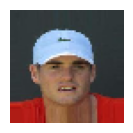

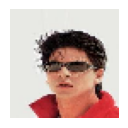

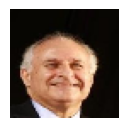

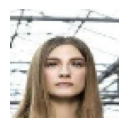

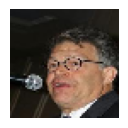

In [20]:
#display sample images
images, _ = next(train_generator)
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")
    plt.show()

In [21]:
#encoder
input_img = Input(shape=(64,64,3))
x = Conv2D(32,(3,3),
           activation="relu",
           padding="same"
)(input_img)
x = MaxPooling2D((2,2),padding="same")(x)
x = Conv2D(64,(3,3),
           activation="relu",
           padding="same"
)(x)
encoded = MaxPooling2D((2,2),padding="same")(x)

In [22]:
#Decoder
x = Conv2D(64,(3,3),
           activation="relu",
           padding="same"
)(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32,(3,3),
           activation="relu",
           padding="same"
)(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(3,(3,3),
                 activation="sigmoid",
                 padding="same"
)(x)

In [23]:
#create Modle
autoencoder = Model(
    input_img,
    decoded
)

In [24]:
#compile model
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

In [25]:

#model summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
#train model
history = autoencoder.fit(
    train_generator,
    epochs=30,
    validation_data=train_generator
)

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - loss: 0.0215 - val_loss: 0.0092
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 0.0080 - val_loss: 0.0070
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 0.0066 - val_loss: 0.0062
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.0061 - val_loss: 0.0058
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 0.0056 - val_loss: 0.0054
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 0.0053 - val_loss: 0.0052
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.0051 - val_loss: 0.0053
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 0.0049 - val_loss: 0.0049
Epoch 9/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - loss: 0.0047 - val_loss: 0.0045
Epoch 10/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.0045 - val_loss: 0.0046
Epoch 11/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.0045 - val_loss: 0.0043
Epoch 12/30
125/125 ━━━━━━━━━━━━━━━━━━━━

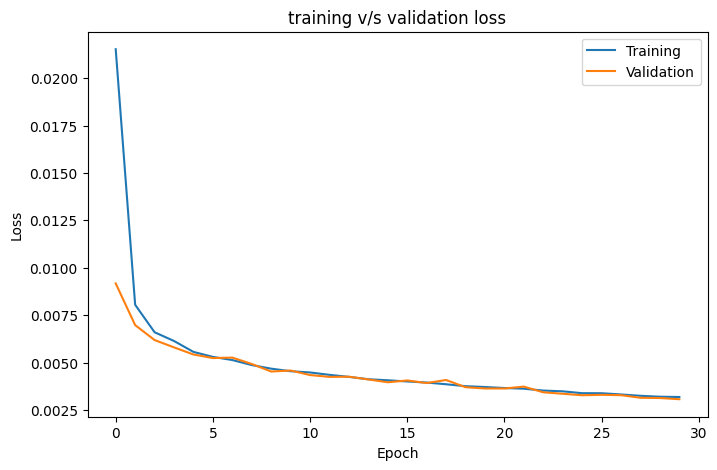

In [27]:
#plot loss
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("training v/s validation loss")

plt.legend(["Training","Validation"])

plt.show()

In [28]:
#evaluate model
loss = autoencoder.evaluate(validation_generator)
print("validation loss:",loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0030
validation loss: 0.0030279841739684343


In [29]:

#Reconstruct images
images,_ = next(validation_generator)
reconstructed_images = autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step


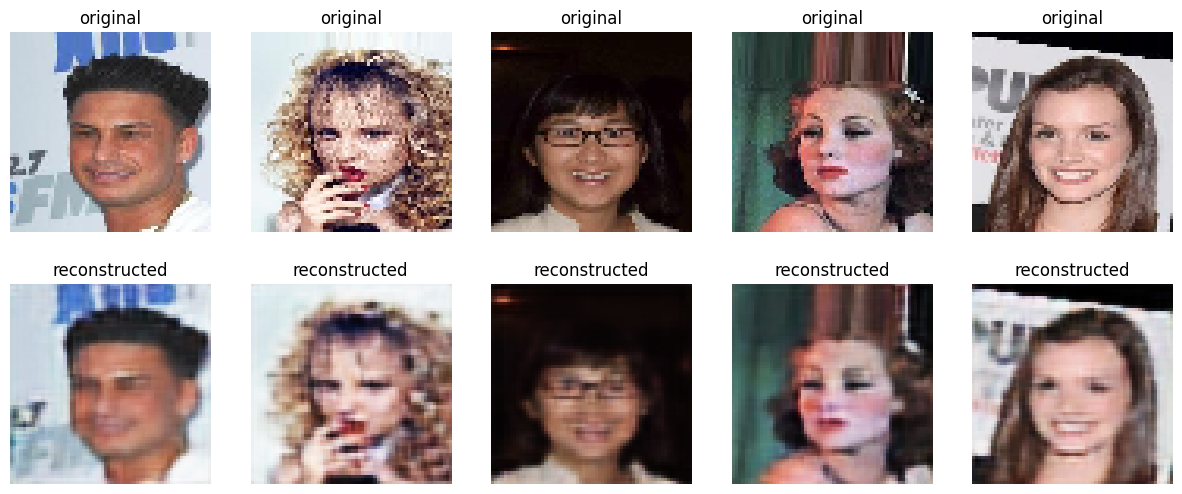

In [30]:
#display results
n=5
plt.figure(figsize=(15,6))
for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(images[i])
    plt.title("original")
    plt.axis("off")
    plt.subplot(2,n,i+1+n)
    plt.imshow(reconstructed_images[i])
    plt.title("reconstructed")
    plt.axis("off")
plt.show()